# 08 — Final Results: AI Exposure and Automatability, 2024 vs 2026

This notebook is the clean findings notebook for the final project. It uses the implemented final models selected in Notebook 6 and applies them to the stratified 300-per-cell sample.

Final implemented models:
- AI exposure: `gpt-5.4`
- Automatability: `gpt-5.4-mini`

Important caveat: these are model-labeled outcomes, not human-coded ground truth. The validation set used for model selection was a Claude-drafted validation audit set, so the final results should be interpreted as model-based estimates rather than definitive labels.

## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve project root from either the project root or /code launch location.
HERE = Path.cwd()
ROOT = next((p for p in [HERE, *HERE.parents] if (p / "data" / "processed").exists()), HERE)
PROC = ROOT / "data" / "processed"
FIGS = ROOT / "output" / "figures"
TABLES = ROOT / "output" / "tables"
FIGS.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

SCORES_PATH = PROC / "final_selected_model_scores_stratified_sample.csv"
print("project root:", ROOT)
print("scores file:", SCORES_PATH)

project root: /Users/PeakViprakasit/QSS45_Final_Project
scores file: /Users/PeakViprakasit/QSS45_Final_Project/data/processed/final_selected_model_scores_stratified_sample.csv


In [2]:
final_scores = pd.read_csv(SCORES_PATH, dtype={"job_id": str})

for col in ["year", "final_exposure_score", "final_automatable_score", "final_exposure", "final_automatable"]:
    final_scores[col] = pd.to_numeric(final_scores[col], errors="coerce")

print("rows:", len(final_scores))
print("exposure scored:", final_scores["final_exposure_score"].notna().sum())
print("automatability scored:", final_scores["final_automatable_score"].notna().sum())
print("years:", sorted(final_scores["year"].dropna().unique()))
final_scores.head()

rows: 2614
exposure scored: 2614
automatability scored: 2614
years: [np.float64(2024.0), np.float64(2026.0)]


,job_id,industry_key,industry_label,year,title_clean,source_platform,final_exposure_score,exposure_rationale,exposure_raw_ok,exposure_model,exposure_provider,final_automatable_score,automatable_rationale,automatable_raw_ok,automatable_model,automatable_provider,final_exposure,final_automatable
0,3901373434,farming_forestry,"Farming, Ranching and Forestry",2024.0,Energy Administrative Assistant,linkedin_2024,0.02,"Clerical, billing, filing, phones, and paperwo...",1,gpt-5.4,openai,0.78,No AI/ML work mentioned; mostly routine cleric...,1,gpt-5.4-mini,openai,0,1
1,3901677982,farming_forestry,"Farming, Ranching and Forestry",2024.0,Forestry Operations Specialist,linkedin_2024,0.12,Operations/logging coordination and training r...,1,gpt-5.4,openai,0.22,Uses technical troubleshooting and training fo...,1,gpt-5.4-mini,openai,0,0
2,3884831631,farming_forestry,"Farming, Ranching and Forestry",2024.0,Production Technician,linkedin_2024,0.03,"Hands-on seed production, shipping, field mana...",1,gpt-5.4,openai,0.18,No AI/ML work described; mostly hands-on seed ...,1,gpt-5.4-mini,openai,0,0
3,3901950699,farming_forestry,"Farming, Ranching and Forestry",2024.0,Production Technician,linkedin_2024,0.06,Production/warehouse tasks use computerized sy...,1,gpt-5.4,openai,0.62,"Uses computers/iPads and automated equipment, ...",1,gpt-5.4-mini,openai,0,1
4,3895550294,farming_forestry,"Farming, Ranching and Forestry",2024.0,Maintenance Area Manager,linkedin_2024,0.02,Maintenance management role; posting shows pla...,1,gpt-5.4,openai,0.12,Maintenance management role; posting emphasize...,1,gpt-5.4-mini,openai,0,0


### Shared figure styling

In [3]:
# ---- presentation visuals: shared palette, theme, aggregates, helpers ----
from matplotlib.patches import FancyArrowPatch
from scipy import stats

df = final_scores.copy()
df["year"] = df["year"].astype(int)
OUT = FIGS  # write into nb08's existing output/figures dir

INK="#16222e"; SUB="#5a6b7b"; FOOTC="#9aa7b4"; GRID="#eef2f6"
C_EXP="#1f6f8b"; C_EXP_L="#b9d4dd"
C_AUTO="#c85d3d"; C_AUTO_L="#ecc6b8"
C_RISE="#1f6f8b"; C_FALL="#9aa7b4"
IND_COLOR={"patent_ip":"#11405c","pharma_chem":"#2f8f8a","legal_services":"#3f7cac",
           "insurance":"#c47a3f","farming_forestry":"#977a55"}
LABEL={"patent_ip":"Patent / IP","pharma_chem":"Pharma / Chemical","legal_services":"Legal Services",
       "insurance":"Insurance","farming_forestry":"Farming & Forestry"}

def THEME():
    plt.rcParams.update({
        "figure.facecolor":"white","axes.facecolor":"white",
        "axes.spines.top":False,"axes.spines.right":False,
        "axes.edgecolor":"#cdd6df","axes.linewidth":1.0,
        "axes.labelcolor":INK,"text.color":INK,"xtick.color":SUB,"ytick.color":SUB,
        "font.size":11,"axes.titleweight":"bold","axes.titlesize":12,
        "axes.grid":True,"grid.color":GRID,"grid.linewidth":1.0,"axes.axisbelow":True,
        "savefig.dpi":200,"savefig.bbox":"tight","figure.dpi":120,
    })
THEME()

def m(year, col): return df[df.year==year][col].mean()
exp24,exp26 = m(2024,"final_exposure_score"), m(2026,"final_exposure_score")
auto24,auto26 = m(2024,"final_automatable_score"), m(2026,"final_automatable_score")
pexp24,pexp26 = m(2024,"final_exposure")*100, m(2026,"final_exposure")*100
pauto24,pauto26 = m(2024,"final_automatable")*100, m(2026,"final_automatable")*100
def welch(col):
    a=df[df.year==2024][col].dropna(); b=df[df.year==2026][col].dropna()
    t,p=stats.ttest_ind(b,a,equal_var=False); return t,p
_,p_exp = welch("final_exposure_score"); _,p_auto = welch("final_automatable_score")

piv_exp = df.pivot_table(index="industry_key",columns="year",values="final_exposure_score",aggfunc="mean")
piv_auto= df.pivot_table(index="industry_key",columns="year",values="final_automatable_score",aggfunc="mean")
ORDER=list(piv_exp[2026].sort_values(ascending=False).index)
N=len(df)
corr=df["final_exposure_score"].corr(df["final_automatable_score"])
FOOT=(f"Model-labeled estimates · stratified sample n={N:,} (LinkedIn postings, 5 industries) · "
      "exposure: gpt-5.4 · automatability: gpt-5.4-mini")

def titleblock(fig, title, subtitle):
    fig.text(0.015,0.965,title,ha="left",va="top",fontsize=15.5,fontweight="bold",color=INK)
    if subtitle: fig.text(0.015,0.905,subtitle,ha="left",va="top",fontsize=10.5,color=SUB)
    fig.text(0.015,0.012,FOOT,ha="left",fontsize=7.5,color=FOOTC)
def save(fig,name): fig.savefig(OUT/name); print("wrote",name)   # no plt.close -> also renders inline
def stars(p): return "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "n.s."
print("presentation-visuals setup ready · figures ->", OUT)

presentation-visuals setup ready · figures -> /Users/PeakViprakasit/QSS45_Final_Project/output/figures


## Sample Balance

In [4]:
sample_balance = (final_scores
    .groupby(["year", "industry_key", "industry_label"])
    .size()
    .reset_index(name="n")
    .sort_values(["year", "industry_key"]))

sample_balance.to_csv(TABLES / "table08_sample_balance.csv", index=False)
sample_balance

,year,industry_key,industry_label,n
0,2024.0,farming_forestry,"Farming, Ranching and Forestry",121
1,2024.0,insurance,Insurance,300
2,2024.0,legal_services,Legal Services,300
3,2024.0,patent_ip,Patent Analysis and IP Research,93
4,2024.0,pharma_chem,Pharmaceutical / Chemical Manufacturing,300
5,2026.0,farming_forestry,"Farming, Ranching and Forestry",300
6,2026.0,insurance,Insurance,300
7,2026.0,legal_services,Legal Services,300
8,2026.0,patent_ip,Patent Analysis and IP Research,300
9,2026.0,pharma_chem,Pharmaceutical / Chemical Manufacturing,300


## Overall 2024 vs 2026 Change

In [5]:
summary_by_year = (final_scores
    .groupby("year")
    .agg(
        n=("job_id", "size"),
        mean_exposure_score=("final_exposure_score", "mean"),
        pct_exposed=("final_exposure", "mean"),
        mean_automatable_score=("final_automatable_score", "mean"),
        pct_automatable=("final_automatable", "mean"),
    )
    .reset_index())

summary_by_year["pct_exposed"] *= 100
summary_by_year["pct_automatable"] *= 100
summary_by_year.to_csv(TABLES / "table08_summary_by_year.csv", index=False)
summary_by_year.round(3)

,year,n,mean_exposure_score,pct_exposed,mean_automatable_score,pct_automatable
0,2024.0,1114,0.061,2.065,0.334,25.583
1,2026.0,1500,0.098,5.667,0.324,23.467


In [6]:
wide_year = summary_by_year.set_index("year")
overall_delta = pd.DataFrame({
    "metric": [
        "Mean AI exposure score",
        "Share exposed to AI (%)",
        "Mean automatability score",
        "Share automatable (%)",
    ],
    "change_2026_minus_2024": [
        wide_year.loc[2026, "mean_exposure_score"] - wide_year.loc[2024, "mean_exposure_score"],
        wide_year.loc[2026, "pct_exposed"] - wide_year.loc[2024, "pct_exposed"],
        wide_year.loc[2026, "mean_automatable_score"] - wide_year.loc[2024, "mean_automatable_score"],
        wide_year.loc[2026, "pct_automatable"] - wide_year.loc[2024, "pct_automatable"],
    ],
})

overall_delta.to_csv(TABLES / "table08_overall_delta.csv", index=False)
overall_delta.round(3)

,metric,change_2026_minus_2024
0,Mean AI exposure score,0.037
1,Share exposed to AI (%),3.602
2,Mean automatability score,-0.010
3,Share automatable (%),-2.117


wrote fig08_mean_scores_by_year.png


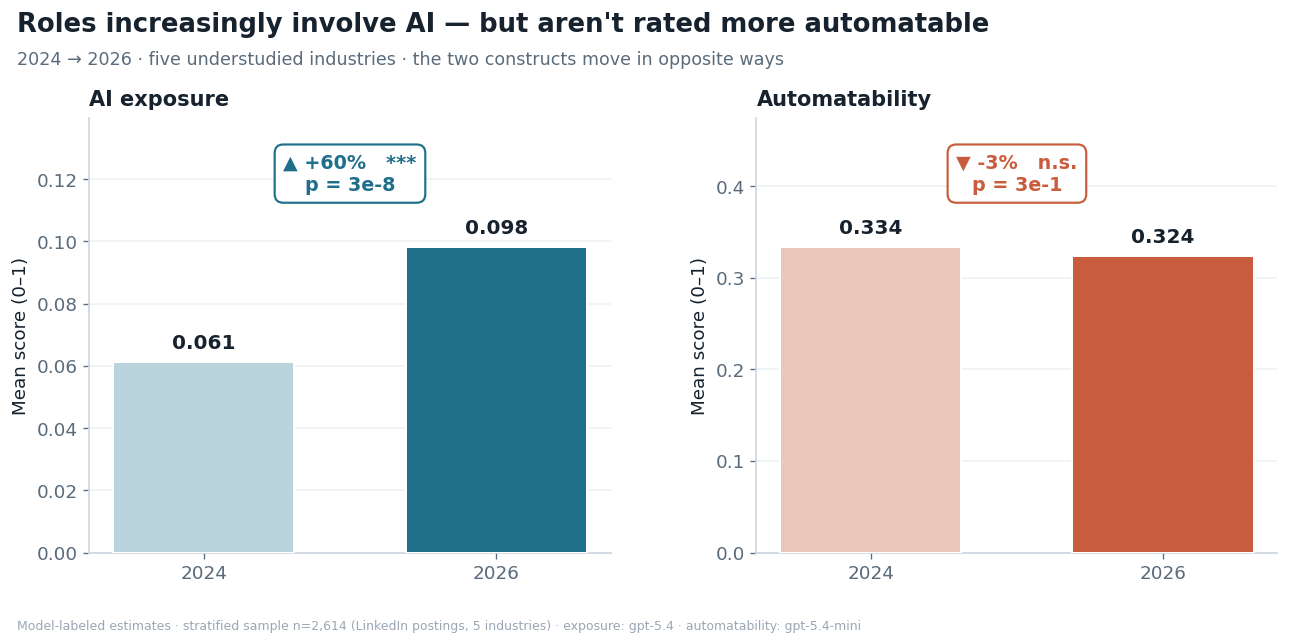

In [7]:
THEME()  # re-assert house style (an earlier cell sets its own rcParams)
fig,(axL,axR)=plt.subplots(1,2,figsize=(11,5.4))
fig.subplots_adjust(top=0.80,bottom=0.13,wspace=0.28,left=0.07,right=0.97)
for ax,(v24,v26,cl,cd,pv,name) in zip(
    (axL,axR),
    [(exp24,exp26,C_EXP_L,C_EXP,p_exp,"AI exposure"),
     (auto24,auto26,C_AUTO_L,C_AUTO,p_auto,"Automatability")]):
    bars=ax.bar(["2024","2026"],[v24,v26],width=0.62,color=[cl,cd],edgecolor="white",linewidth=1.2,zorder=3)
    ax.set_ylim(0,max(v24,v26)*1.42)
    for x,v in zip([0,1],[v24,v26]):
        ax.text(x,v+max(v24,v26)*0.03,f"{v:.3f}",ha="center",va="bottom",fontsize=12,fontweight="bold",color=INK)
    pct=(v26/v24-1)*100
    arrow="▲" if pct>1 else ("▼" if pct<-1 else "▬")
    txt=f"{arrow} {pct:+.0f}%   {stars(pv)}\np = {pv:.0e}".replace("e-0","e-")
    ax.text(0.5,0.92,txt,transform=ax.transAxes,ha="center",va="top",fontsize=11.5,
            color=cd,fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.45",fc="white",ec=cd,lw=1.3))
    ax.set_title(name,loc="left",fontsize=12.5,color=INK,pad=8)
    ax.set_ylabel("Mean score (0–1)")
    ax.grid(axis="x",visible=False)
titleblock(fig,"Roles increasingly involve AI — but aren't rated more automatable",
           "2024 → 2026 · five understudied industries · the two constructs move in opposite ways")
save(fig,"fig08_mean_scores_by_year.png")

wrote fig08_classification_rates_by_year.png


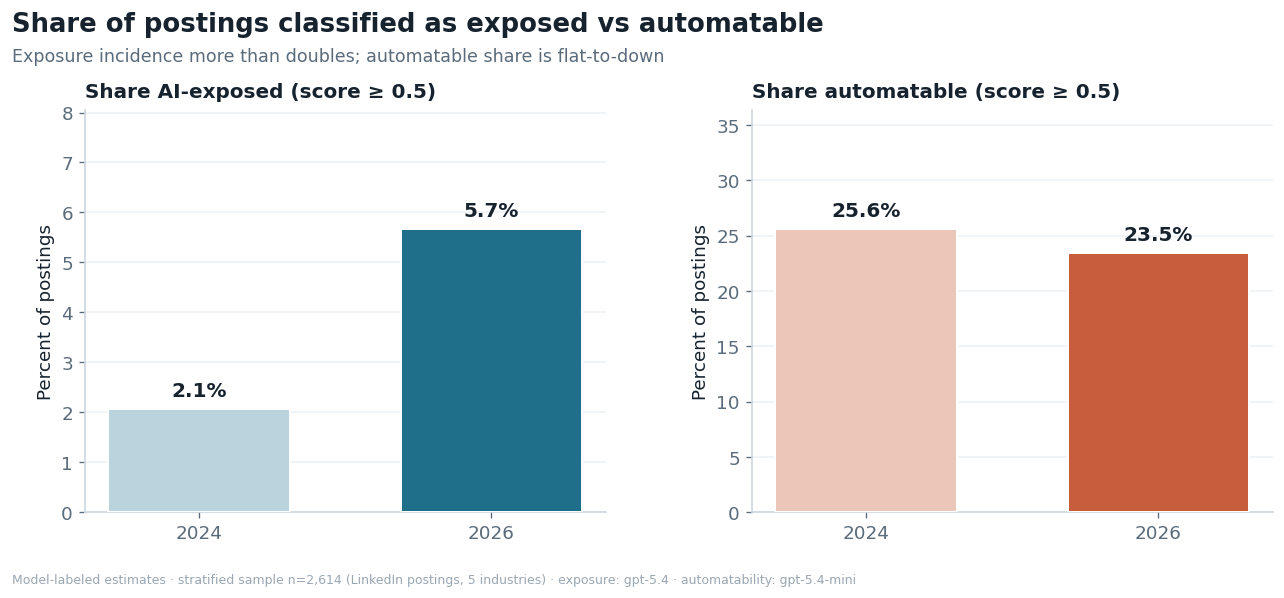

In [8]:
THEME()  # re-assert house style (an earlier cell sets its own rcParams)
fig,(axL,axR)=plt.subplots(1,2,figsize=(11,5.0))
fig.subplots_adjust(top=0.80,bottom=0.13,wspace=0.28,left=0.07,right=0.97)
for ax,(v24,v26,cl,cd,name) in zip(
    (axL,axR),
    [(pexp24,pexp26,C_EXP_L,C_EXP,"Share AI-exposed (score ≥ 0.5)"),
     (pauto24,pauto26,C_AUTO_L,C_AUTO,"Share automatable (score ≥ 0.5)")]):
    ax.bar(["2024","2026"],[v24,v26],width=0.62,color=[cl,cd],edgecolor="white",linewidth=1.2,zorder=3)
    ax.set_ylim(0,max(v24,v26)*1.42)
    for x,v in zip([0,1],[v24,v26]):
        ax.text(x,v+max(v24,v26)*0.03,f"{v:.1f}%",ha="center",va="bottom",fontsize=12,fontweight="bold",color=INK)
    ax.set_title(name,loc="left",fontsize=12,color=INK,pad=8); ax.set_ylabel("Percent of postings")
    ax.grid(axis="x",visible=False)
titleblock(fig,"Share of postings classified as exposed vs automatable",
           "Exposure incidence more than doubles; automatable share is flat-to-down")
save(fig,"fig08_classification_rates_by_year.png")

## Industry-Level Differences

In [9]:
industry_year = (final_scores
    .groupby(["industry_key", "industry_label", "year"])
    .agg(
        n=("job_id", "size"),
        mean_exposure_score=("final_exposure_score", "mean"),
        pct_exposed=("final_exposure", "mean"),
        mean_automatable_score=("final_automatable_score", "mean"),
        pct_automatable=("final_automatable", "mean"),
    )
    .reset_index())

industry_year["pct_exposed"] *= 100
industry_year["pct_automatable"] *= 100
industry_year.to_csv(TABLES / "table08_industry_year.csv", index=False)
industry_year.round(3)

,industry_key,industry_label,year,n,mean_exposure_score,pct_exposed,mean_automatable_score,pct_automatable
0,farming_forestry,"Farming, Ranching and Forestry",2024.0,121,0.077,4.132,0.319,23.140
1,farming_forestry,"Farming, Ranching and Forestry",2026.0,300,0.056,2.333,0.335,26.000
2,insurance,Insurance,2024.0,300,0.090,4.000,0.349,25.667
3,insurance,Insurance,2026.0,300,0.079,3.333,0.357,23.333
4,legal_services,Legal Services,2024.0,300,0.032,0.000,0.355,31.333
5,legal_services,Legal Services,2026.0,300,0.100,6.333,0.359,33.000
6,patent_ip,Patent Analysis and IP Research,2024.0,93,0.047,0.000,0.314,23.656
7,patent_ip,Patent Analysis and IP Research,2026.0,300,0.151,10.333,0.298,19.000
8,pharma_chem,Pharmaceutical / Chemical Manufacturing,2024.0,300,0.060,2.000,0.309,21.333
9,pharma_chem,Pharmaceutical / Chemical Manufacturing,2026.0,300,0.105,6.000,0.271,16.000


In [10]:
delta_tables = []
for metric in ["mean_exposure_score", "pct_exposed", "mean_automatable_score", "pct_automatable"]:
    piv = industry_year.pivot(index=["industry_key", "industry_label"], columns="year", values=metric).reset_index()
    piv.columns.name = None
    piv = piv.rename(columns={2024.0: "2024", 2026.0: "2026"})
    piv["metric"] = metric
    piv["delta_2026_minus_2024"] = piv["2026"] - piv["2024"]
    delta_tables.append(piv[["industry_key", "industry_label", "metric", "2024", "2026", "delta_2026_minus_2024"]])

industry_deltas = pd.concat(delta_tables, ignore_index=True)
industry_deltas.to_csv(TABLES / "table08_industry_deltas.csv", index=False)
industry_deltas.round(3)

,industry_key,industry_label,metric,2024,2026,delta_2026_minus_2024
0,farming_forestry,"Farming, Ranching and Forestry",mean_exposure_score,0.077,0.056,-0.021
1,insurance,Insurance,mean_exposure_score,0.090,0.079,-0.011
2,legal_services,Legal Services,mean_exposure_score,0.032,0.100,0.068
3,patent_ip,Patent Analysis and IP Research,mean_exposure_score,0.047,0.151,0.104
4,pharma_chem,Pharmaceutical / Chemical Manufacturing,mean_exposure_score,0.060,0.105,0.045
5,farming_forestry,"Farming, Ranching and Forestry",pct_exposed,4.132,2.333,-1.799
6,insurance,Insurance,pct_exposed,4.000,3.333,-0.667
7,legal_services,Legal Services,pct_exposed,0.000,6.333,6.333
8,patent_ip,Patent Analysis and IP Research,pct_exposed,0.000,10.333,10.333
9,pharma_chem,Pharmaceutical / Chemical Manufacturing,pct_exposed,2.000,6.000,4.000


## Five-Industry Breakdown

The next figures separate the final results by industry. They are designed for the paper/presentation: the first chart compares 2024 and 2026 levels, the second emphasizes change, and the third summarizes each industry's exposure/automatability profile.

In [11]:
# Presentation-style labels and colors.
industry_order = [
    "farming_forestry",
    "insurance",
    "legal_services",
    "patent_ip",
    "pharma_chem",
]
industry_short = {
    "farming_forestry": "Farming &\nForestry",
    "insurance": "Insurance",
    "legal_services": "Legal\nServices",
    "patent_ip": "Patent/IP",
    "pharma_chem": "Pharma/\nChemical",
}
industry_long = dict(final_scores[["industry_key", "industry_label"]].drop_duplicates().values)

COLORS = {
    "2024": "#7c8da6",
    "2026": "#1f6f8b",
    "exposure": "#1f6f8b",
    "automation": "#c85d3d",
    "neutral": "#d8dee8",
    "text": "#1f2933",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c8d0d9",
    "axes.labelcolor": COLORS["text"],
    "xtick.color": COLORS["text"],
    "ytick.color": COLORS["text"],
    "font.size": 10,
    "axes.titleweight": "bold",
})

industry_plot = industry_year.copy()
industry_plot["industry_short"] = industry_plot["industry_key"].map(industry_short)
industry_plot["industry_key"] = pd.Categorical(industry_plot["industry_key"], categories=industry_order, ordered=True)
industry_plot = industry_plot.sort_values(["industry_key", "year"])

industry_delta_plot = industry_deltas.copy()
industry_delta_plot["industry_short"] = industry_delta_plot["industry_key"].map(industry_short)
industry_delta_plot["industry_key"] = pd.Categorical(industry_delta_plot["industry_key"], categories=industry_order, ordered=True)
industry_delta_plot = industry_delta_plot.sort_values("industry_key")

industry_plot.round(3)

def one_line_label(key):
    return industry_short[key].replace(chr(10), " ")


wrote fig08_industry_exposure_2024_2026_grouped.png
wrote fig08_industry_automatability_2024_2026_grouped.png


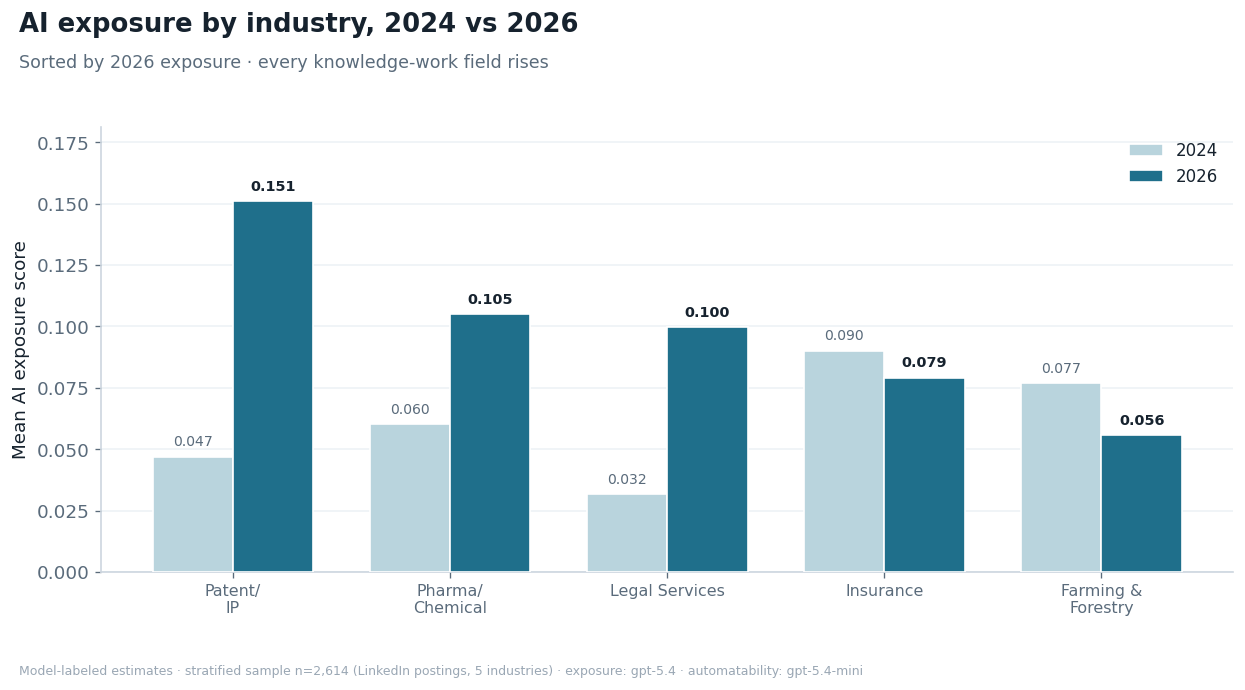

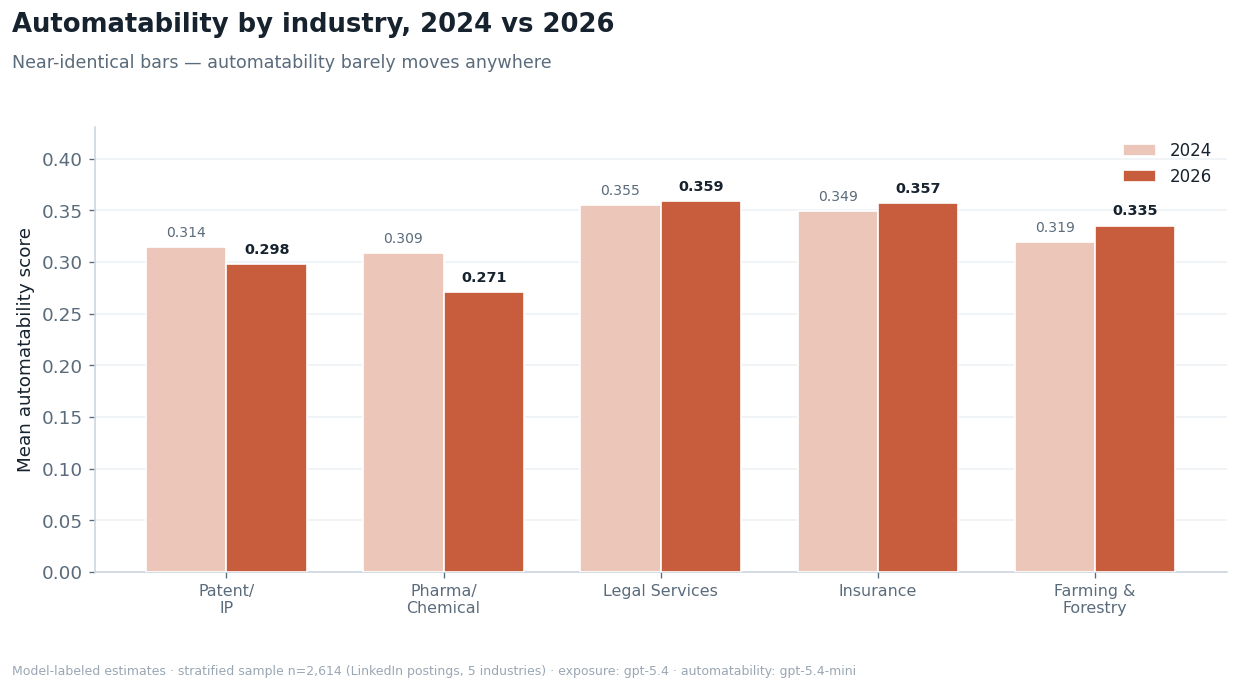

In [12]:
THEME()  # re-assert house style (an earlier cell sets its own rcParams)
def grouped(piv,cd,cl,ylabel,title,subtitle,name,pct=False):
    fig,ax=plt.subplots(figsize=(10.6,5.8)); fig.subplots_adjust(top=0.80,bottom=0.16,left=0.08,right=0.97)
    x=np.arange(len(ORDER)); w=0.37
    v24=[piv.loc[k,2024]*(100 if pct else 1) for k in ORDER]
    v26=[piv.loc[k,2026]*(100 if pct else 1) for k in ORDER]
    ax.bar(x-w/2,v24,w,color=cl,edgecolor="white",lw=1,label="2024",zorder=3)
    ax.bar(x+w/2,v26,w,color=cd,edgecolor="white",lw=1,label="2026",zorder=3)
    top=max(max(v24),max(v26))
    for xi,v in zip(x-w/2,v24): ax.text(xi,v+top*0.02,(f"{v:.1f}%" if pct else f"{v:.3f}"),ha="center",va="bottom",fontsize=8.4,color=SUB)
    for xi,v in zip(x+w/2,v26): ax.text(xi,v+top*0.02,(f"{v:.1f}%" if pct else f"{v:.3f}"),ha="center",va="bottom",fontsize=8.6,color=INK,fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels([LABEL[k].replace(" / ","/\n").replace(" & "," &\n") for k in ORDER],fontsize=9.5)
    ax.set_ylabel(ylabel); ax.set_ylim(0,top*1.2); ax.grid(axis="x",visible=False)
    ax.legend(frameon=False,loc="upper right",fontsize=10)
    titleblock(fig,title,subtitle); save(fig,name)
grouped(piv_exp,C_EXP,C_EXP_L,"Mean AI exposure score",
        "AI exposure by industry, 2024 vs 2026","Sorted by 2026 exposure · every knowledge-work field rises",
        "fig08_industry_exposure_2024_2026_grouped.png")
grouped(piv_auto,C_AUTO,C_AUTO_L,"Mean automatability score",
        "Automatability by industry, 2024 vs 2026","Near-identical bars — automatability barely moves anywhere",
        "fig08_industry_automatability_2024_2026_grouped.png")

wrote fig08_exposure_by_industry_slope.png


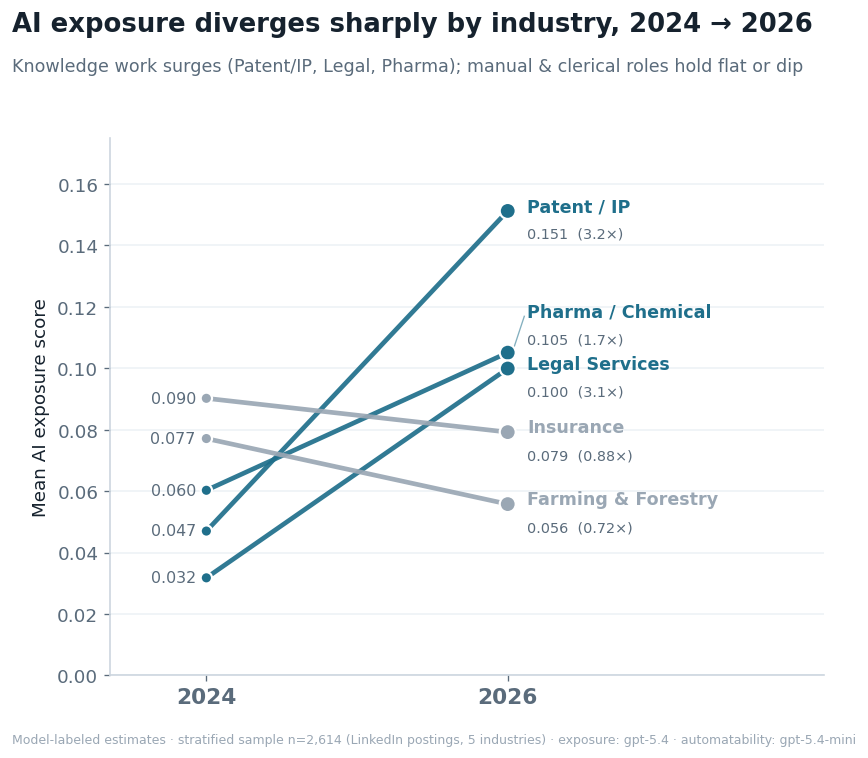

In [13]:
THEME()  # re-assert house style (an earlier cell sets its own rcParams)
fig,ax=plt.subplots(figsize=(9.6,6.4))
fig.subplots_adjust(top=0.80,bottom=0.10,left=0.10,right=0.72)
x0,x1=0.0,1.0
# declutter right-side label anchors: enforce a minimum vertical gap
lab_y={k:piv_exp.loc[k,2026] for k in ORDER}
for a,b in zip(sorted(ORDER,key=lambda k:lab_y[k])[:-1],
               sorted(ORDER,key=lambda k:lab_y[k])[1:]):
    if lab_y[b]-lab_y[a]<0.017: lab_y[b]=lab_y[a]+0.017
for key in ORDER:
    y0,y1=piv_exp.loc[key,2024],piv_exp.loc[key,2026]
    rising=y1>=y0; col=C_RISE if rising else C_FALL
    ax.plot([x0,x1],[y0,y1],color=col,lw=2.8,alpha=0.92,zorder=2,solid_capstyle="round")
    ax.scatter([x0,x1],[y0,y1],s=[46,92],color=col,edgecolor="white",lw=1.3,zorder=3)
    ax.text(x0-0.035,y0,f"{y0:.3f}",ha="right",va="center",fontsize=9.5,color=SUB)
    ly=lab_y[key]
    if abs(ly-y1)>1e-4:  # faint leader when the label was nudged off its dot
        ax.plot([x1+0.015,x1+0.055],[y1,ly],color=col,lw=0.8,alpha=0.55,zorder=2)
    mult=y1/y0 if y0>0 else np.nan
    tag=f"  ({mult:.1f}×)" if rising else f"  ({mult:.2f}×)"
    ax.text(x1+0.065,ly+0.0015,f"{LABEL[key]}",ha="left",va="center",fontsize=10.5,
            color=col,fontweight="bold")
    ax.text(x1+0.065,ly-0.0075,f"{y1:.3f}{tag}",ha="left",va="center",fontsize=8.6,color=SUB)
ax.set_xlim(-0.32,2.05); ax.set_ylim(0,0.175)
ax.set_xticks([x0,x1]); ax.set_xticklabels(["2024","2026"],fontsize=13,fontweight="bold")
ax.set_ylabel("Mean AI exposure score"); ax.grid(axis="x",visible=False)
titleblock(fig,"AI exposure diverges sharply by industry, 2024 → 2026",
           "Knowledge work surges (Patent/IP, Legal, Pharma); manual & clerical roles hold flat or dip")
save(fig,"fig08_exposure_by_industry_slope.png")

wrote fig08_industry_exposure_delta_lollipop.png


wrote fig08_industry_automatability_delta_lollipop.png


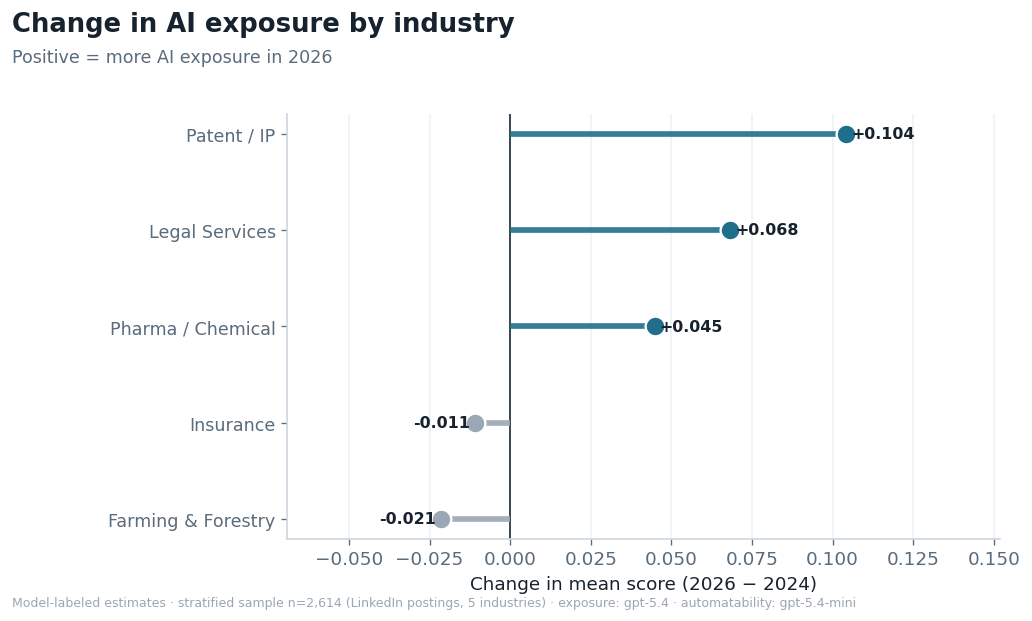

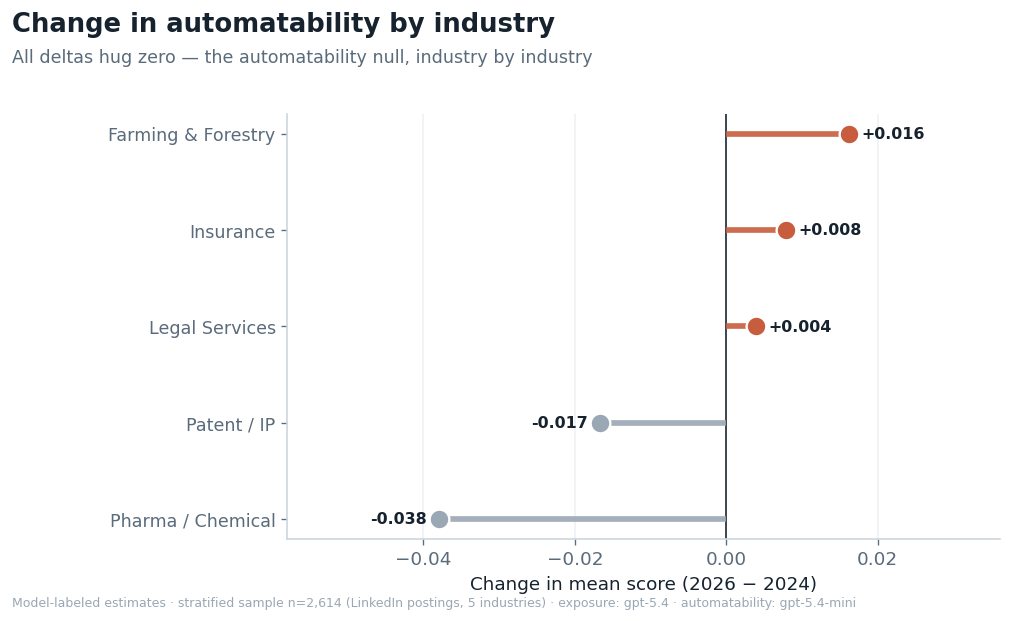

In [14]:
THEME()  # re-assert house style (an earlier cell sets its own rcParams)
def lolli(piv,title,subtitle,name,rise_c):
    d=(piv[2026]-piv[2024]).reindex(ORDER)
    d=d.sort_values()
    fig,ax=plt.subplots(figsize=(9.0,5.2)); fig.subplots_adjust(top=0.80,bottom=0.12,left=0.27,right=0.93)
    y=np.arange(len(d))
    ax.axvline(0,color="#2f3a45",lw=1.1,zorder=1)
    for yi,(k,val) in zip(y,d.items()):
        c=rise_c if val>=0 else C_FALL
        ax.hlines(yi,0,val,color=c,lw=3.4,alpha=0.9,zorder=2)
        ax.scatter(val,yi,s=140,color=c,edgecolor="white",lw=1.4,zorder=3)
        ax.text(val+(0.0016 if val>=0 else -0.0016),yi,f"{val:+.3f}",
                va="center",ha="left" if val>=0 else "right",fontsize=9.5,fontweight="bold",color=INK)
    ax.set_yticks(y); ax.set_yticklabels([LABEL[k] for k in d.index],fontsize=10.5)
    pad=max(abs(d.min()),abs(d.max()))*0.42+0.004
    ax.set_xlim(d.min()-pad,d.max()+pad); ax.set_xlabel("Change in mean score (2026 − 2024)")
    ax.grid(axis="y",visible=False)
    titleblock(fig,title,subtitle); save(fig,name)
lolli(piv_exp,"Change in AI exposure by industry","Positive = more AI exposure in 2026",
      "fig08_industry_exposure_delta_lollipop.png",C_EXP)
lolli(piv_auto,"Change in automatability by industry","All deltas hug zero — the automatability null, industry by industry",
      "fig08_industry_automatability_delta_lollipop.png",C_AUTO)

wrote fig08_industry_profile_exposure_vs_automation.png


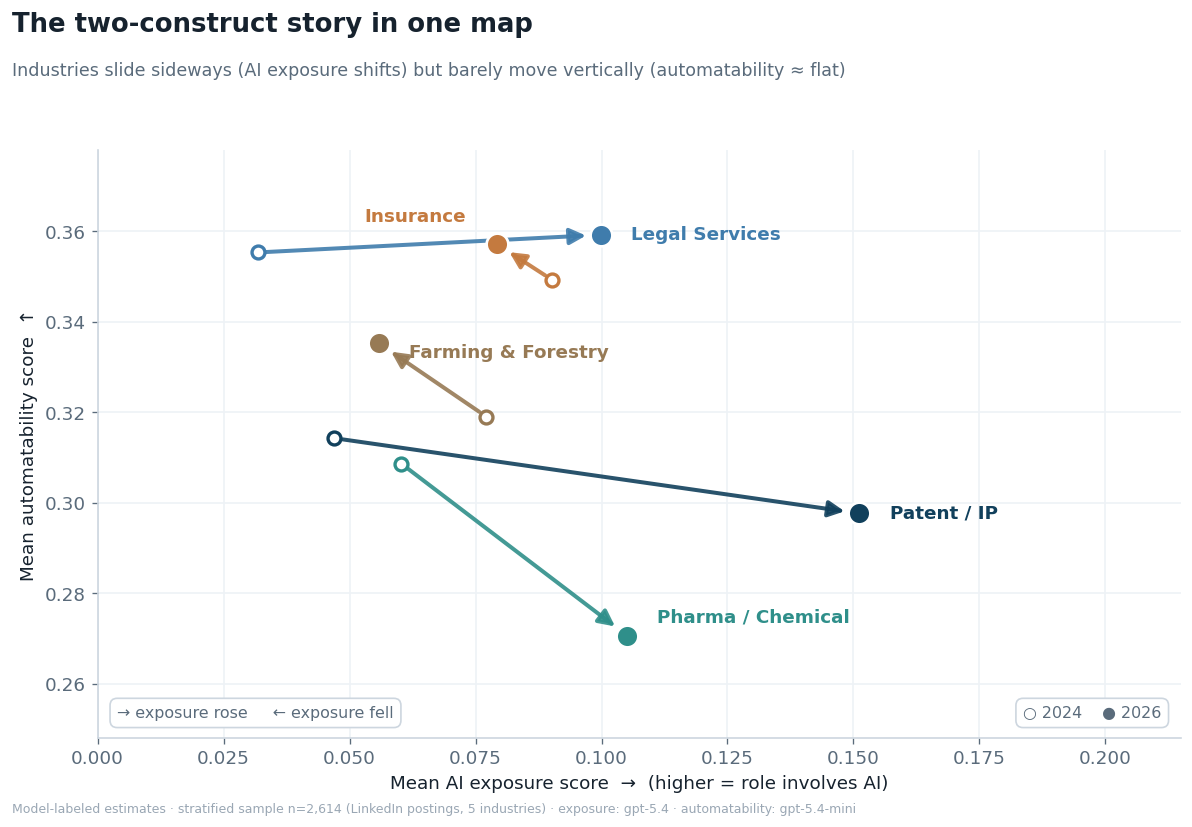

In [15]:
THEME()  # re-assert house style (an earlier cell sets its own rcParams)
fig,ax=plt.subplots(figsize=(10.2,7.0)); fig.subplots_adjust(top=0.80,bottom=0.10,left=0.085,right=0.97)
# per-industry 2026-label placement (dx, dy, ha) tuned to dodge arrows/each-other
LBL_OFF={"patent_ip":(+0.006,0.000,"left"),
         "pharma_chem":(+0.006,+0.004,"left"),
         "legal_services":(+0.006,0.000,"left"),
         "insurance":(-0.006,+0.006,"right"),
         "farming_forestry":(+0.006,-0.002,"left")}
for key in ORDER:
    x0,y0=piv_exp.loc[key,2024],piv_auto.loc[key,2024]
    x1,y1=piv_exp.loc[key,2026],piv_auto.loc[key,2026]
    c=IND_COLOR[key]
    arr=FancyArrowPatch((x0,y0),(x1,y1),arrowstyle="-|>",mutation_scale=20,
                        lw=2.4,color=c,alpha=0.9,shrinkA=5,shrinkB=9,zorder=2)
    ax.add_patch(arr)
    ax.scatter(x0,y0,s=60,facecolor="white",edgecolor=c,lw=2.0,zorder=3)
    ax.scatter(x1,y1,s=170,color=c,edgecolor="white",lw=1.6,zorder=4)
    dx,dy,ha=LBL_OFF[key]
    ax.text(x1+dx,y1+dy,LABEL[key],fontsize=11,color=c,va="center",ha=ha,fontweight="bold")
ax.set_xlim(0,0.215); ax.set_ylim(0.248,0.378)
ax.set_xlabel("Mean AI exposure score  →  (higher = role involves AI)")
ax.set_ylabel("Mean automatability score  ↑")
ax.text(0.982,0.03,"○ 2024    ● 2026",transform=ax.transAxes,ha="right",va="bottom",
        fontsize=9.5,color=SUB,bbox=dict(boxstyle="round,pad=0.45",fc="white",ec="#cdd6df"))
ax.text(0.018,0.03,"→ exposure rose     ← exposure fell",transform=ax.transAxes,
        ha="left",va="bottom",fontsize=9.5,color=SUB,
        bbox=dict(boxstyle="round,pad=0.45",fc="white",ec="#cdd6df"))
titleblock(fig,"The two-construct story in one map",
           "Industries slide sideways (AI exposure shifts) but barely move vertically (automatability ≈ flat)")
save(fig,"fig08_industry_profile_exposure_vs_automation.png")

In [16]:
# Cleaner table for the slide/write-up: one row per industry.
industry_slide_table = industry_year.pivot(index=["industry_key", "industry_label"], columns="year", values=[
    "mean_exposure_score", "mean_automatable_score", "pct_exposed", "pct_automatable"
]).reset_index()
industry_slide_table.columns = [str(c[0]) if c[1] == "" else f"{c[0]}_{int(c[1])}" for c in industry_slide_table.columns]
industry_slide_table["exposure_score_change"] = industry_slide_table["mean_exposure_score_2026"] - industry_slide_table["mean_exposure_score_2024"]
industry_slide_table["automatable_score_change"] = industry_slide_table["mean_automatable_score_2026"] - industry_slide_table["mean_automatable_score_2024"]
industry_slide_table = industry_slide_table[[
    "industry_key", "industry_label",
    "mean_exposure_score_2024", "mean_exposure_score_2026", "exposure_score_change",
    "mean_automatable_score_2024", "mean_automatable_score_2026", "automatable_score_change",
    "pct_exposed_2024", "pct_exposed_2026", "pct_automatable_2024", "pct_automatable_2026",
]]
industry_slide_table.to_csv(TABLES / "table08_industry_slide_summary.csv", index=False)
industry_slide_table.round(3)

,industry_key,industry_label,mean_exposure_score_2024,mean_exposure_score_2026,exposure_score_change,mean_automatable_score_2024,mean_automatable_score_2026,automatable_score_change,pct_exposed_2024,pct_exposed_2026,pct_automatable_2024,pct_automatable_2026
0,farming_forestry,"Farming, Ranching and Forestry",0.077,0.056,-0.021,0.319,0.335,0.016,4.132,2.333,23.140,26.000
1,insurance,Insurance,0.090,0.079,-0.011,0.349,0.357,0.008,4.000,3.333,25.667,23.333
2,legal_services,Legal Services,0.032,0.100,0.068,0.355,0.359,0.004,0.000,6.333,31.333,33.000
3,patent_ip,Patent Analysis and IP Research,0.047,0.151,0.104,0.314,0.298,-0.017,0.000,10.333,23.656,19.000
4,pharma_chem,Pharmaceutical / Chemical Manufacturing,0.060,0.105,0.045,0.309,0.271,-0.038,2.000,6.000,21.333,16.000


## Relationship Between Exposure and Automatability

AI exposure and automatability are related but conceptually different. A job can mention or use AI tools without being highly automatable, and a job can be automatable because routine tasks are described even when AI is not explicitly emphasized.

In [17]:
score_corr = final_scores[["final_exposure_score", "final_automatable_score"]].corr().iloc[0, 1]
classification_crosswalk = pd.crosstab(
    final_scores["final_exposure"],
    final_scores["final_automatable"],
    normalize="all"
) * 100

print("Correlation between final exposure and automatability scores:", round(score_corr, 3))
classification_crosswalk.round(2)

Correlation between final exposure and automatability scores: -0.108


final_automatable,0,1
final_exposure,,
0,71.88,23.99
1,3.75,0.38


wrote fig08_exposure_vs_automatability_scatter.png


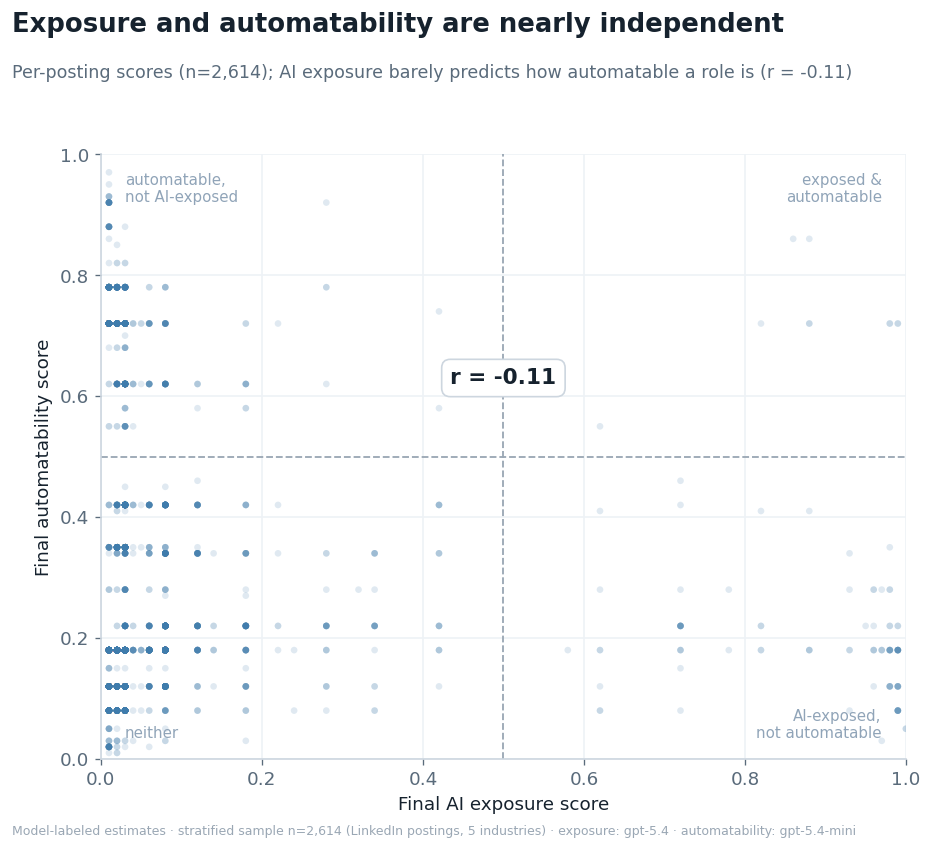

In [18]:
THEME()  # re-assert house style (an earlier cell sets its own rcParams)
corr=df["final_exposure_score"].corr(df["final_automatable_score"])
fig,ax=plt.subplots(figsize=(7.8,7.2)); fig.subplots_adjust(top=0.80,bottom=0.10,left=0.11,right=0.97)
ax.scatter(df.final_exposure_score,df.final_automatable_score,s=16,alpha=0.16,
           color="#3f7cac",edgecolors="none",zorder=2)
ax.axvline(0.5,ls="--",color="#9aa7b4",lw=1.1); ax.axhline(0.5,ls="--",color="#9aa7b4",lw=1.1)
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_xlabel("Final AI exposure score"); ax.set_ylabel("Final automatability score")
quad=[(0.97,0.97,"exposed &\nautomatable","right","top"),
      (0.03,0.97,"automatable,\nnot AI-exposed","left","top"),
      (0.97,0.03,"AI-exposed,\nnot automatable","right","bottom"),
      (0.03,0.03,"neither","left","bottom")]
for qx,qy,t,ha,va in quad:
    ax.text(qx,qy,t,transform=ax.transAxes,ha=ha,va=va,fontsize=9,color="#90a4b8")
ax.text(0.5,0.62,f"r = {corr:+.2f}",transform=ax.transAxes,ha="center",fontsize=13,
        fontweight="bold",color=INK,bbox=dict(boxstyle="round,pad=0.4",fc="white",ec="#cdd6df"))
titleblock(fig,"Exposure and automatability are nearly independent",
           f"Per-posting scores (n={N:,}); AI exposure barely predicts how automatable a role is (r = {corr:+.2f})")
save(fig,"fig08_exposure_vs_automatability_scatter.png")

## Write-Up Bullets

Run the next cell to print short prose bullets for the paper and presentation. Edit wording as needed, but keep the limitation that these are model-based estimates.

In [19]:
def fmt_pct(x):
    return f"{x:.1f}%"

y24 = summary_by_year.set_index("year").loc[2024]
y26 = summary_by_year.set_index("year").loc[2026]
d = overall_delta.set_index("metric")["change_2026_minus_2024"]

largest_exp = industry_deltas[industry_deltas.metric.eq("mean_exposure_score")].sort_values("delta_2026_minus_2024", ascending=False).iloc[0]
smallest_exp = industry_deltas[industry_deltas.metric.eq("mean_exposure_score")].sort_values("delta_2026_minus_2024", ascending=True).iloc[0]
largest_auto = industry_deltas[industry_deltas.metric.eq("mean_automatable_score")].sort_values("delta_2026_minus_2024", ascending=False).iloc[0]
smallest_auto = industry_deltas[industry_deltas.metric.eq("mean_automatable_score")].sort_values("delta_2026_minus_2024", ascending=True).iloc[0]

bullets = [
    f"The final analysis uses {len(final_scores):,} stratified postings scored by the selected LLM labelers, with up to 300 postings per year-industry cell.",
    f"Average AI exposure changed from {y24.mean_exposure_score:.3f} in 2024 to {y26.mean_exposure_score:.3f} in 2026, a 2026-minus-2024 change of {d['Mean AI exposure score']:.3f}.",
    f"The share classified as AI-exposed changed from {fmt_pct(y24.pct_exposed)} in 2024 to {fmt_pct(y26.pct_exposed)} in 2026.",
    f"Average automatability changed from {y24.mean_automatable_score:.3f} in 2024 to {y26.mean_automatable_score:.3f} in 2026, a change of {d['Mean automatability score']:.3f}.",
    f"The share classified as automatable changed from {fmt_pct(y24.pct_automatable)} in 2024 to {fmt_pct(y26.pct_automatable)} in 2026.",
    f"The largest increase in AI exposure score was in {largest_exp.industry_label} ({largest_exp.delta_2026_minus_2024:.3f}); the largest decrease was in {smallest_exp.industry_label} ({smallest_exp.delta_2026_minus_2024:.3f}).",
    f"The largest increase in automatability score was in {largest_auto.industry_label} ({largest_auto.delta_2026_minus_2024:.3f}); the largest decrease was in {smallest_auto.industry_label} ({smallest_auto.delta_2026_minus_2024:.3f}).",
    f"Exposure and automatability scores are correlated at r = {score_corr:.3f}, which supports treating them as related but distinct constructs.",
]

for b in bullets:
    print("- " + b)

- The final analysis uses 2,614 stratified postings scored by the selected LLM labelers, with up to 300 postings per year-industry cell.
- Average AI exposure changed from 0.061 in 2024 to 0.098 in 2026, a 2026-minus-2024 change of 0.037.
- The share classified as AI-exposed changed from 2.1% in 2024 to 5.7% in 2026.
- Average automatability changed from 0.334 in 2024 to 0.324 in 2026, a change of -0.010.
- The share classified as automatable changed from 25.6% in 2024 to 23.5% in 2026.
- The largest increase in AI exposure score was in Patent Analysis and IP Research (0.104); the largest decrease was in Farming, Ranching and Forestry (-0.021).
- The largest increase in automatability score was in Farming, Ranching and Forestry (0.016); the largest decrease was in Pharmaceutical / Chemical Manufacturing (-0.038).
- Exposure and automatability scores are correlated at r = -0.108, which supports treating them as related but distinct constructs.


## Presentation Slide Notes

Suggested 4-minute slide sequence:

1. Research question and data: LinkedIn postings, 2024 vs 2026, five industries.
2. Modeling choice: BERT/classical baselines underperformed LLM labelers on the validation audit.
3. Final implementation: `gpt-5.4` for exposure, `gpt-5.4-mini` for automatability, 2,614-posting stratified sample.
4. Overall change: use `fig08_mean_scores_by_year.png` or `fig08_classification_rates_by_year.png`.
5. Industry differences: use one industry delta chart.
6. Takeaway and limitations: model-labeled outcomes, small audit set, LinkedIn sample, descriptive not causal.

## Posting-level density & distribution shift

wrote fig08_joint_density_posting_level.png


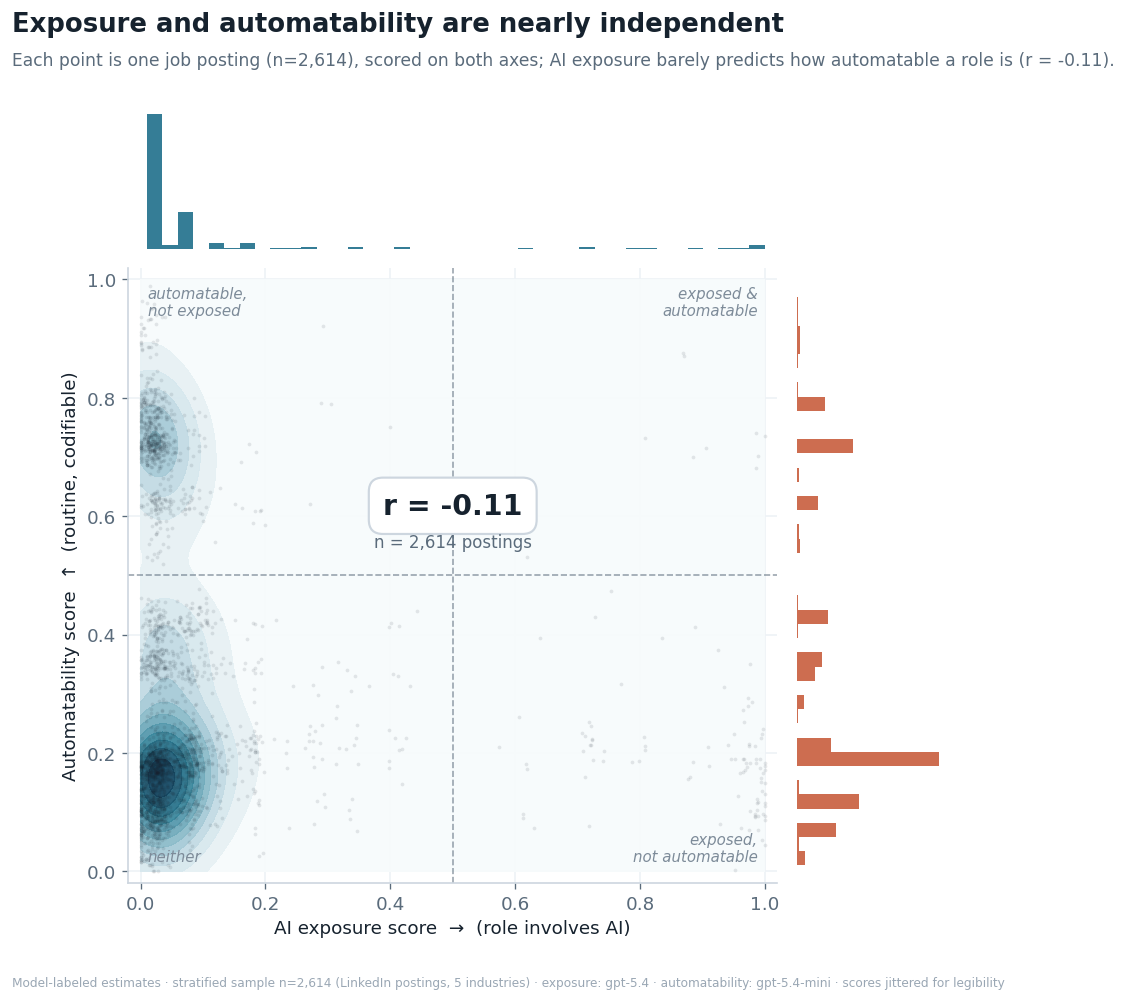

In [20]:
# Joint density of the two constructs at the POSTING level (fixes the '5-point correlation' optics).
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
TEAL = LinearSegmentedColormap.from_list("teal", ["#ffffff","#cfe3ea","#7fb4c4","#2f7f96","#11405c"])
_d = df.dropna(subset=["final_exposure_score","final_automatable_score"])
_x = _d.final_exposure_score.values; _y = _d.final_automatable_score.values; _N = len(_d)
_r = np.corrcoef(_x, _y)[0, 1]
_rng = np.random.default_rng(42)
_jx = np.clip(_x + _rng.normal(0, 0.012, _N), 0, 1)   # jitter discrete scores so the cloud reads as a cloud
_jy = np.clip(_y + _rng.normal(0, 0.018, _N), 0, 1)
THEME()
fig = plt.figure(figsize=(8.8, 8.4))
gs = GridSpec(2, 2, width_ratios=[5, 1.15], height_ratios=[1.15, 5], hspace=0.05, wspace=0.05)
ax = fig.add_subplot(gs[1, 0]); axt = fig.add_subplot(gs[0, 0], sharex=ax); axr = fig.add_subplot(gs[1, 1], sharey=ax)
_kde = stats.gaussian_kde(np.vstack([_jx, _jy]))
_gx, _gy = np.mgrid[0:1:200j, 0:1:200j]
_dens = _kde(np.vstack([_gx.ravel(), _gy.ravel()])).reshape(_gx.shape)
ax.contourf(_gx, _gy, _dens, levels=12, cmap=TEAL, alpha=0.95)
ax.scatter(_jx, _jy, s=5, color=INK, alpha=0.10, linewidths=0, zorder=2)
ax.axvline(0.5, color=SUB, lw=1, ls="--", alpha=0.6); ax.axhline(0.5, color=SUB, lw=1, ls="--", alpha=0.6)
for qx, qy, t, ha, va in [(0.97,0.97,"exposed &\nautomatable","right","top"),
                          (0.03,0.97,"automatable,\nnot exposed","left","top"),
                          (0.97,0.03,"exposed,\nnot automatable","right","bottom"),
                          (0.03,0.03,"neither","left","bottom")]:
    ax.text(qx, qy, t, transform=ax.transAxes, ha=ha, va=va, fontsize=9, color="#7d8b99", style="italic")
ax.text(0.5, 0.60, f"r = {_r:+.2f}", transform=ax.transAxes, ha="center", fontsize=17, fontweight="bold",
        color=INK, bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#cdd6df", lw=1.3))
ax.text(0.5, 0.545, f"n = {_N:,} postings", transform=ax.transAxes, ha="center", fontsize=10, color=SUB)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("AI exposure score  →  (role involves AI)")
ax.set_ylabel("Automatability score  ↑  (routine, codifiable)")
axt.hist(_x, bins=40, color=C_EXP, alpha=0.9); axt.axis("off")
axr.hist(_y, bins=40, orientation="horizontal", color=C_AUTO, alpha=0.9); axr.axis("off")
fig.text(0.015, 0.975, "Exposure and automatability are nearly independent", ha="left", va="top",
         fontsize=15.5, fontweight="bold", color=INK)
fig.text(0.015, 0.935, f"Each point is one job posting (n={_N:,}), scored on both axes; AI exposure barely predicts how automatable a role is (r = {_r:+.2f}).",
         ha="left", va="top", fontsize=10.3, color=SUB)
fig.text(0.015, 0.008, FOOT + " · scores jittered for legibility", ha="left", fontsize=7.3, color=FOOTC)
save(fig, "fig08_joint_density_posting_level.png")

wrote fig08_distribution_shift_ecdf.png


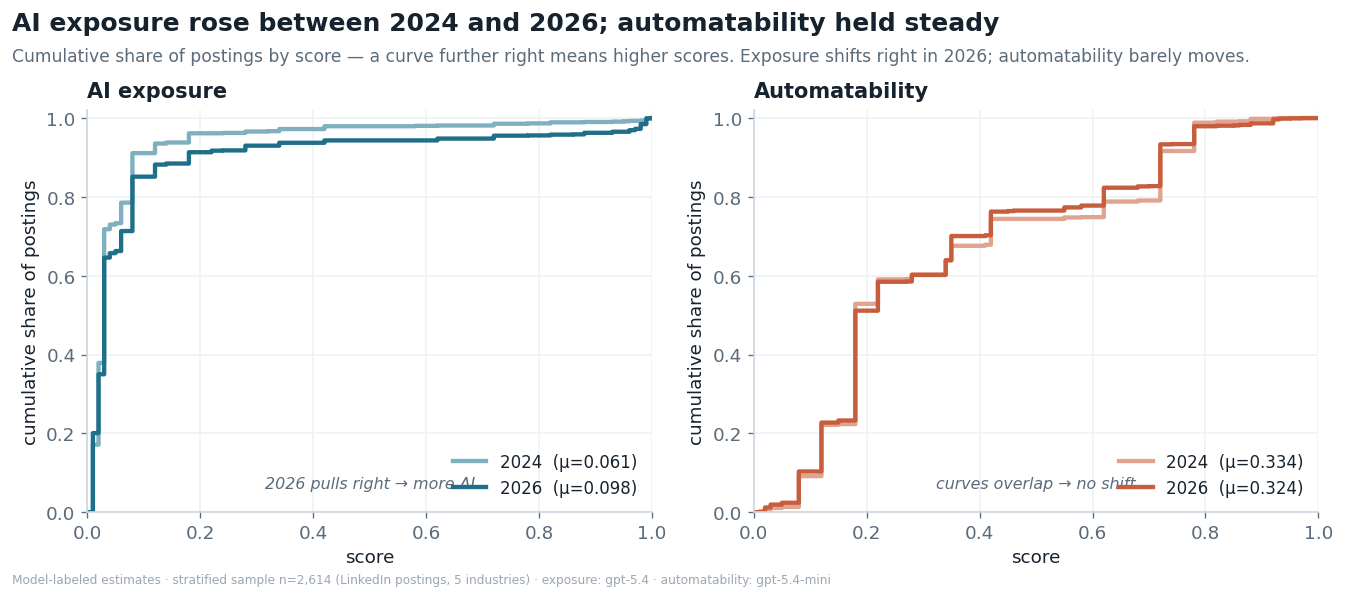

In [21]:
# Full 2024->2026 distribution shift (ECDF) for both constructs.
THEME()
fig, axes = plt.subplots(1, 2, figsize=(11.4, 5.0))
fig.subplots_adjust(top=0.80, bottom=0.13, wspace=0.18, left=0.07, right=0.97)
for ax, (col, cd, cl, name, note) in zip(axes, [
        ("final_exposure_score", C_EXP, "#7fb0c0", "AI exposure", "2026 pulls right → more AI"),
        ("final_automatable_score", C_AUTO, "#e0a48f", "Automatability", "curves overlap → no shift")]):
    for yr, c in [(2024, cl), (2026, cd)]:
        v = np.sort(df[df.year == yr][col].dropna().values); cdf = np.arange(1, len(v) + 1) / len(v)
        ax.step(np.concatenate([[0], v, [1]]), np.concatenate([[0], cdf, [1]]), where="post",
                color=c, lw=2.6, label=f"{yr}  (μ={v.mean():.3f})")
    ax.set_title(name, loc="left", fontsize=12.5, pad=8); ax.set_xlabel("score")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02); ax.set_ylabel("cumulative share of postings")
    ax.legend(loc="lower right", frameon=False, fontsize=10)
    ax.text(0.5, 0.06, note, transform=ax.transAxes, ha="center", fontsize=9.5, color=SUB, style="italic")
    ax.grid(True, color=GRID)
fig.text(0.015, 0.965, "AI exposure rose between 2024 and 2026; automatability held steady",
         ha="left", va="top", fontsize=15, fontweight="bold", color=INK)
fig.text(0.015, 0.905, "Cumulative share of postings by score — a curve further right means higher scores. Exposure shifts right in 2026; automatability barely moves.",
         ha="left", va="top", fontsize=10.3, color=SUB)
fig.text(0.015, 0.012, FOOT, ha="left", fontsize=7.3, color=FOOTC)
save(fig, "fig08_distribution_shift_ecdf.png")